# Inverse Kinematics Robot Planar 3-DOF Menggunakan Machine Learning

### Praktikum RE-608 Legged Robot

**Nama:** Yosua Dirgana Pratama  
**NIM:** 4222301009

---

### Tujuan Praktikum

1. Membangun model robot planar 3-DOF menggunakan forward kinematics.
2. Menghasilkan dataset inverse kinematics.
3. Melakukan optimasi machine learning untuk memprediksi sudut joint robot.
4. Membandingkan performa beberapa metode machine learning.
5. Menganalisis pengaruh perubahan panjang link robot terhadap workspace dan reachability.

---

# 🦾 Inverse Kinematics Planar Robot 3-DOF
## Pendekatan Machine Learning, Deep Learning, dan Reinforcement Learning

---
> **Prasyarat:** Python, NumPy, dasar ML & Neural Network  
> **Tools:** `numpy`, `matplotlib`, `scikit-learn`, `torch`, `gymnasium`, `stable-baselines3`




---
## 📖 Bagian 1: Pengantar Forward & Inverse Kinematics

### Apa itu Kinematika Robot?

**Forward Kinematics (FK):** Diberikan sudut sendi → hitung posisi end-effector  
- Mudah ✅, solusi **unik**

**Inverse Kinematics (IK):** Diberikan posisi target → hitung sudut sendi  
- Sulit ⚠️, solusi bisa **banyak** atau **tidak ada**

### Robot Planar 3-DOF
- 3 link (lengan): `L1=0.4m`, `L2=0.3m`, `L3=0.2m`
- 3 sendi (joint): `θ1, θ2, θ3` (dalam radian)
- End-effector: ujung lengan ke-3

### Persamaan FK:
```
x = L1·cos(θ1) + L2·cos(θ1+θ2) + L3·cos(θ1+θ2+θ3)
y = L1·sin(θ1) + L2·sin(θ1+θ2) + L3·sin(θ1+θ2+θ3)
```

### 3 Pendekatan IK dengan AI:
| Pendekatan | Metode | Kelebihan |
|------------|--------|-----------|
| **ML** | Supervised (KNN, RF, SVR) | Cepat, mudah dipahami |
| **DL** | Neural Network (PyTorch) | Akurat, generalisasi baik |
| **RL** | Gymnasium + PPO | Adaptif, bisa dapat obstacle |


---
## 🛠️ Bagian 2: Setup & Visualisasi Robot

In [37]:
# Install dependencies (jalankan sekali)
!pip install gymnasium stable-baselines3 scikit-learn torch matplotlib numpy tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")

✅ Library siap!



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


===== KONFIGURASI ROBOT =====
Link lama : [0.4, 0.3, 0.2]
Link baru : [0.5, 0.4, 0.3]
Maximum Reach : 1.2 m

===== PERBANDINGAN HASIL =====
Workspace lama : 0.90 m
Workspace baru : 1.20 m
Peningkatan Reachability : 33.33%


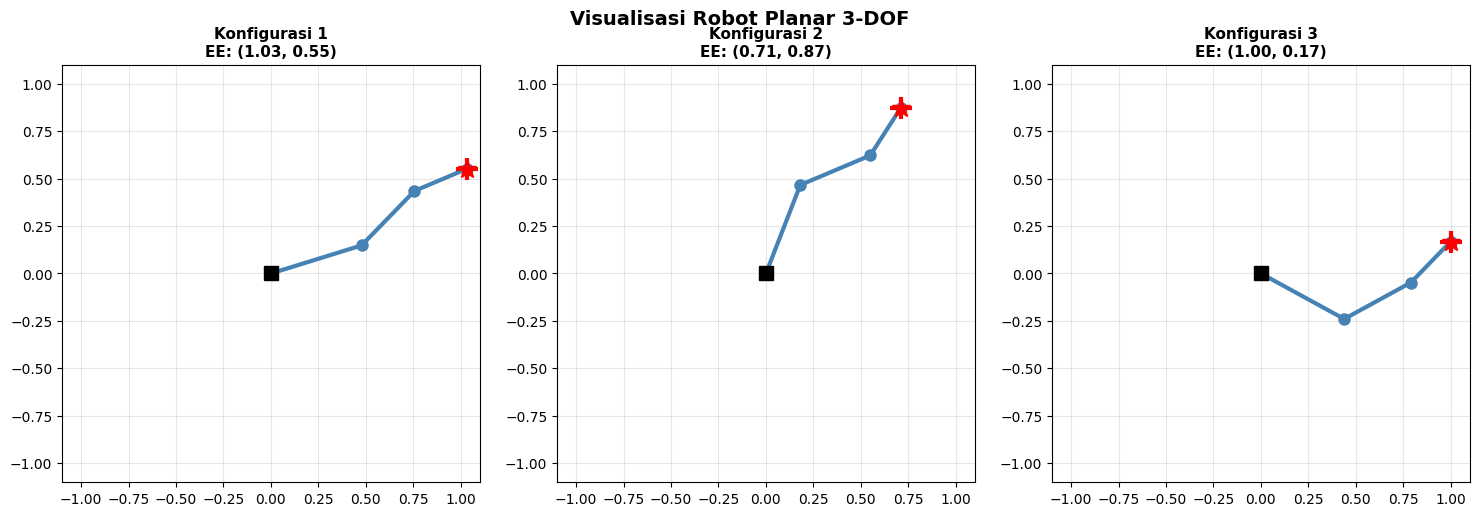

✅ Robot berhasil divisualisasi!


In [38]:
# ─── Konfigurasi Robot ───────────────────────────────────────────────

# konfigurasi lama (untuk pembanding)
old_links = [0.4, 0.3, 0.2]

# konfigurasi baru (sesuai tugas)
new_links = [0.5, 0.4, 0.3]

# assign panjang link
L1, L2, L3 = new_links

LINK_LENGTHS = np.array([L1, L2, L3])

JOINT_LIMIT = np.pi

MAX_REACH = L1 + L2 + L3


# ===== KONFIGURASI ROBOT =====

print("===== KONFIGURASI ROBOT =====")
print("Link lama :", old_links)
print("Link baru :", new_links)
print(f"Maximum Reach : {MAX_REACH:.1f} m")


# ===== PERBANDINGAN HASIL =====

workspace_old = sum(old_links)

workspace_new = sum(new_links)

improvement = (
    (workspace_new - workspace_old)
    / workspace_old
) * 100

print("\n===== PERBANDINGAN HASIL =====")

print(f"Workspace lama : {workspace_old:.2f} m")

print(f"Workspace baru : {workspace_new:.2f} m")

print(f"Peningkatan Reachability : {improvement:.2f}%")


# ─── Forward Kinematics ──────────────────────────────────────────────

def forward_kinematics(theta):
    """Hitung posisi setiap sendi dari sudut theta = [θ1, θ2, θ3]."""

    t1, t2, t3 = theta

    p0 = np.array([0.0, 0.0])

    p1 = p0 + L1*np.array([
        np.cos(t1),
        np.sin(t1)
    ])

    p2 = p1 + L2*np.array([
        np.cos(t1+t2),
        np.sin(t1+t2)
    ])

    p3 = p2 + L3*np.array([
        np.cos(t1+t2+t3),
        np.sin(t1+t2+t3)
    ])

    return p0, p1, p2, p3


def get_end_effector(theta):
    """Return posisi end-effector."""

    return forward_kinematics(theta)[3]


# ─── Fungsi Plot Robot ───────────────────────────────────────────────

def plot_robot(ax, theta, target=None,
               title="Robot",
               color='steelblue'):

    p0, p1, p2, p3 = forward_kinematics(theta)

    points = np.array([p0,p1,p2,p3])

    ax.plot(
        points[:,0],
        points[:,1],
        '-o',
        color=color,
        linewidth=3,
        markersize=8
    )

    ax.plot(*p0,'ks',markersize=10)

    ax.plot(
        *p3,
        '*',
        color='red',
        markersize=14,
        label='End-effector'
    )

    if target is not None:

        ax.plot(
            *target,
            'r+',
            markersize=16,
            markeredgewidth=3,
            label='Target'
        )

        ax.add_patch(
            Circle(
                target,
                0.02,
                color='red',
                alpha=0.3
            )
        )

    ax.set_xlim(-1.1,1.1)
    ax.set_ylim(-1.1,1.1)

    ax.set_aspect('equal')

    ax.grid(True,alpha=0.3)

    ax.set_title(
        title,
        fontsize=11,
        fontweight='bold'
    )


# ─── Demo Visualisasi Robot ──────────────────────────────────────────

fig, axes = plt.subplots(1,3,figsize=(15,5))

configs = [

    ([0.3,0.5,-0.4],"Konfigurasi 1"),

    ([1.2,-0.8,0.6],"Konfigurasi 2"),

    ([-0.5,1.0,0.3],"Konfigurasi 3")

]

for ax,(theta,title) in zip(axes,configs):

    ee = get_end_effector(theta)

    plot_robot(
        ax,
        theta,
        target=ee,
        title=f"{title}\nEE: ({ee[0]:.2f}, {ee[1]:.2f})"
    )

plt.suptitle(
    "Visualisasi Robot Planar 3-DOF",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

print("✅ Robot berhasil divisualisasi!")

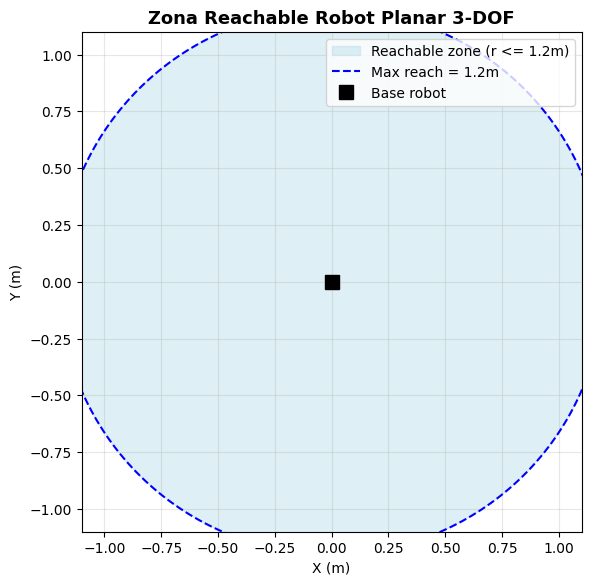

Demo Reachability Check:
  Target               | Jarak    | Reachable?
  ---------------------------------------------
  (0.5, 0.3)             | 0.5831 m | YES
  (0.8, 0.6)             | 1.0000 m | YES
  (1.0, 0.0)             | 1.0000 m | YES
  (1.1, 0.0)             | 1.1000 m | YES
  (0.0, 0.0)             | 0.0000 m | NO


In [39]:
# ─── Fungsi Reachability Check ───────────────────────────────────────
def is_reachable(target, tol=1e-6):
    """
    Cek apakah posisi target dapat dijangkau robot planar 3-DOF.

    Syarat reachable:
      dist_from_origin <= MAX_REACH (= L1+L2+L3 = 0.9 m)

    Karena joint tidak dibatasi arah, MIN_REACH = 0
    (robot bisa dilipat sehingga semua link saling menghapus).
    """
    target = np.array(target, dtype=float)
    dist = np.linalg.norm(target)
    min_reach = abs(L1 - L2 - L3)   # = 0 untuk konfigurasi ini
    return bool(min_reach - tol <= dist <= MAX_REACH + tol)

def filter_reachable(positions, labels=None):
    """Filter array posisi, kembalikan hanya yang reachable."""
    mask = np.array([is_reachable(p) for p in positions])
    if labels is not None:
        return positions[mask], labels[mask], mask
    return positions[mask], mask

# ─── Visualisasi Zona Reachable ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
theta_range = np.linspace(0, 2*np.pi, 300)
ax.fill(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        color='lightblue', alpha=0.4, label=f'Reachable zone (r <= {MAX_REACH}m)')
ax.plot(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        'b--', linewidth=1.5, label=f'Max reach = {MAX_REACH}m')
ax.plot(0, 0, 'ks', markersize=10, label='Base robot')
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Zona Reachable Robot Planar 3-DOF", fontsize=13, fontweight='bold')
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ─── Demo cek reachability ────────────────────────────────────────────
test_points = [(0.5, 0.3), (0.8, 0.6), (1.0, 0.0), (1.1, 0.0), (0.0, 0.0)]
print("Demo Reachability Check:")
print(f"  {'Target':20s} | {'Jarak':8s} | {'Reachable?':10s}")
print("  " + "-"*45)
for pt in test_points:
    d = np.linalg.norm(pt)
    r = is_reachable(pt)
    status = "YES" if r else "NO"
    print(f"  ({pt[0]:.1f}, {pt[1]:.1f}){'':12} | {d:.4f} m | {status}")


---
## 📊 Bagian 3: Membuat Dataset (Sampling FK)

✅ Dataset dibuat: 50000 sampel
   Reachable  : 46973 (93.9%)
   Unreachable: 3027 (6.1%)
   ⚠️  3027 sampel dibuang (tidak reachable)
   ✅ Dataset bersih: 46973 sampel
   Input  (theta): shape=(46973, 3)     → [θ1, θ2, θ3]
   Output (EE pos): shape=(46973, 2) → [x, y]


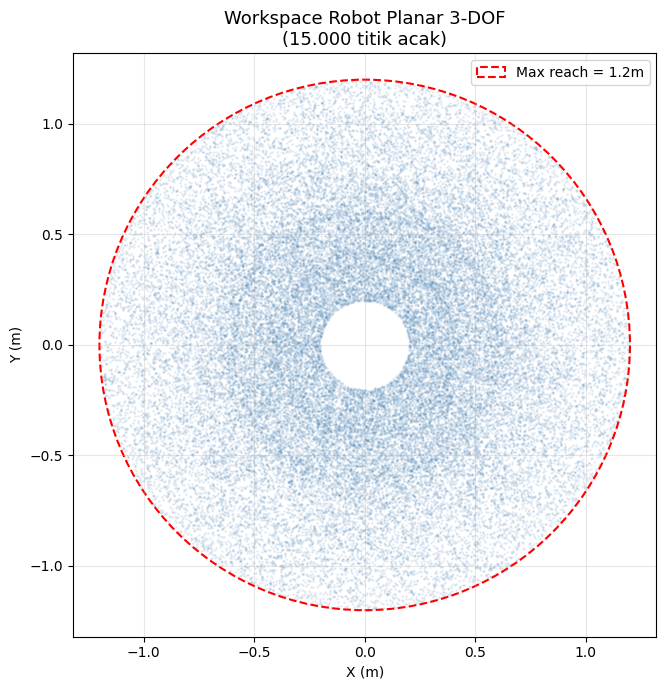

✅ Workspace tervisualisasi!


In [40]:
# ─── Generate Dataset ────────────────────────────────────────────────
np.random.seed(42)
N = 50000  # jumlah sampel

# Random sudut sendi
thetas = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, size=(N, 3)).astype(np.float32)

# Hitung posisi end-effector via FK
ee_positions = np.array([get_end_effector(t) for t in thetas], dtype=np.float32)

# ─── Validasi Reachability Dataset ──────────────────────────────────
_, reach_mask = filter_reachable(ee_positions)
n_reachable = int(reach_mask.sum())
n_unreachable = N - n_reachable
print(f"✅ Dataset dibuat: {N} sampel")
print(f"   Reachable  : {n_reachable} ({n_reachable/N*100:.1f}%)")
print(f"   Unreachable: {n_unreachable} ({n_unreachable/N*100:.1f}%)")
if n_unreachable > 0:
    print(f"   ⚠️  {n_unreachable} sampel dibuang (tidak reachable)")
    ee_positions = ee_positions[reach_mask]
    thetas       = thetas[reach_mask]
    print(f"   ✅ Dataset bersih: {len(ee_positions)} sampel")
else:
    print("   ✅ Semua sampel reachable (expected, karena dari FK sampling)")
print(f"   Input  (theta): shape={thetas.shape}     → [θ1, θ2, θ3]")
print(f"   Output (EE pos): shape={ee_positions.shape} → [x, y]")

# ─── Visualisasi Workspace Robot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ee_positions[:,0], ee_positions[:,1],
           alpha=0.1, s=1, color='steelblue')
ax.set_title("Workspace Robot Planar 3-DOF\n(50.000 titik acak)", fontsize=13)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
circle = plt.Circle((0,0), MAX_REACH, fill=False, color='red',
                     linestyle='--', linewidth=1.5, label=f'Max reach = {MAX_REACH}m')
ax.add_patch(circle)
ax.legend(); plt.tight_layout(); plt.show()
print("✅ Workspace tervisualisasi!")


In [41]:
# ─── Split Dataset ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# X = posisi target (ee_positions), y = sudut sendi (thetas)
X_train, X_test, y_train, y_test = train_test_split(
    ee_positions, thetas, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} sampel")
print(f"Test : {X_test.shape[0]} sampel")


Train: 37578 sampel
Test : 9395 sampel


---
## 🤖 Bagian 4: Pendekatan 1 — Machine Learning (Supervised)

**Ide:** Buat model regresi dari data (x,y) → (θ1,θ2,θ3)  
Model akan belajar memetakan posisi target ke sudut sendi.


In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import time

# ─── Normalisasi ─────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

ml_results = {}

# ─── 1. KNN ───────────────────────────────────────────────────────────

print("🔵 Training KNN...")

t0 = time.time()

knn = KNeighborsRegressor(

    n_neighbors=5,

    weights='distance',

    metric='euclidean',

    n_jobs=-1

)

knn.fit(X_train_s, y_train)

knn_pred = knn.predict(X_test_s)

t_knn = time.time() - t0


# Hitung error end-effector

knn_ee = np.array([
    get_end_effector(p)
    for p in knn_pred
])

knn_err = np.linalg.norm(
    knn_ee - X_test,
    axis=1
)

ml_results['KNN'] = {

    'pred': knn_pred,

    'ee_err': knn_err,

    'time': t_knn

}

print(
f"✅ KNN — mean EE error: {knn_err.mean()*100:.2f} cm | time: {t_knn:.1f}s"
)

# ─── 2. Random Forest ─────────────────────────────────────────────────

print("🌲 Training Random Forest...")

rf = RandomForestRegressor(

    n_estimators=500,

    max_depth=None,

    max_features='sqrt',

    random_state=42,

    n_jobs=-1

)

t0 = time.time()

rf.fit(X_train_s, y_train)

rf_pred = rf.predict(X_test_s)

t_rf = time.time() - t0


# Hitung error end-effector

rf_ee = np.array([
    get_end_effector(p)
    for p in rf_pred
])

rf_err = np.linalg.norm(
    rf_ee - X_test,
    axis=1
)

ml_results['Random Forest'] = {

    'pred': rf_pred,

    'ee_err': rf_err,

    'time': t_rf

}

print(
f"✅ RF — mean EE error: {rf_err.mean()*100:.2f} cm | time: {t_rf:.1f}s"
)
from sklearn.ensemble import ExtraTreesRegressor

# ─── 3. Extra Trees ───────────────────────────────────────────────

print("🌳 Training Extra Trees...")

t0 = time.time()

et = ExtraTreesRegressor(

    n_estimators=500,

    random_state=42,

    n_jobs=-1

)

et.fit(X_train_s, y_train)

et_pred = et.predict(X_test_s)

t_et = time.time() - t0


# Hitung error end-effector

et_ee = np.array([

    get_end_effector(p)

    for p in et_pred

])

et_err = np.linalg.norm(

    et_ee - X_test,

    axis=1

)

ml_results['Extra Trees'] = {

    'pred': et_pred,

    'ee_err': et_err,

    'time': t_et

}

print(

f"✅ ET — mean EE error: {et_err.mean()*100:.2f} cm | time: {t_et:.1f}s"

)

🔵 Training KNN...
✅ KNN — mean EE error: 58.26 cm | time: 0.1s
🌲 Training Random Forest...
✅ RF — mean EE error: 66.06 cm | time: 8.9s
🌳 Training Extra Trees...
✅ ET — mean EE error: 59.77 cm | time: 19.7s


## Perbandingan Model Machine Learning

Dilakukan evaluasi performa KNN, Random Forest, dan Extra Trees menggunakan mean end-effector error.

In [43]:
print("\n===== PERBANDINGAN MODEL =====")

print(f"KNN Error : {knn_err.mean()*100:.2f} cm")

print(f"RF Error  : {rf_err.mean()*100:.2f} cm")

print(f"ET Error  : {et_err.mean()*100:.2f} cm")

# Tentukan model terbaik
best_ml = min(
    [("KNN", knn_err.mean()*100),
     ("Random Forest", rf_err.mean()*100),
     ("Extra Trees", et_err.mean()*100)],
    key=lambda x: x[1]
)
print(f"\n🏆 Model ML terbaik: {best_ml[0]} ({best_ml[1]:.2f} cm)")


===== PERBANDINGAN MODEL =====
KNN Error : 58.26 cm
RF Error  : 66.06 cm
ET Error  : 59.77 cm


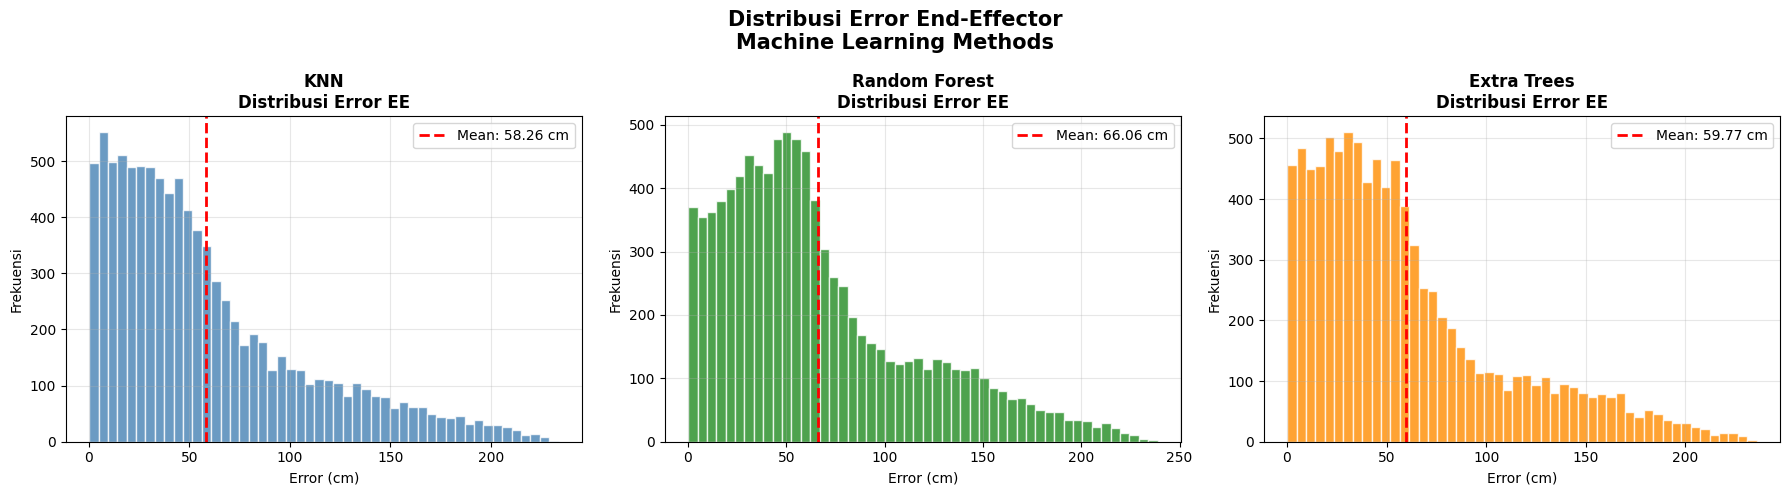

In [65]:
# ─── Visualisasi Error ML ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [

    ('KNN', ml_results['KNN']),

    ('Random Forest', ml_results['Random Forest']),

    ('Extra Trees', ml_results['Extra Trees'])

]

colors = [

    'steelblue',

    'forestgreen',

    'darkorange'

]

for ax, (name, res), color in zip(axes, models, colors):

    ax.hist(

        res['ee_err'] * 100,

        bins=50,

        color=color,

        edgecolor='white',

        alpha=0.8

    )

    ax.axvline(

        res['ee_err'].mean() * 100,

        color='red',

        linestyle='--',

        linewidth=2,

        label=f"Mean: {res['ee_err'].mean()*100:.2f} cm"

    )

    ax.set_title(

        f"{name}\nDistribusi Error EE",

        fontsize=12,

        fontweight='bold'

    )

    ax.set_xlabel("Error (cm)")

    ax.set_ylabel("Frekuensi")

    ax.grid(True, alpha=0.3)

    ax.legend()

plt.suptitle(

    "Distribusi Error End-Effector\nMachine Learning Methods",

    fontsize=15,

    fontweight='bold'

)

plt.tight_layout()

plt.show()

In [45]:
# ─── Cek Reachability Target Sebelum Prediksi (ML) ──────────────────
print("Cek reachability 5 sampel target test:")
for j, t in enumerate(X_test[:5]):
    r = is_reachable(t)
    d = np.linalg.norm(t)
    status = "YES" if r else "NO"
    print(f"   Target {j+1}: ({t[0]:.3f}, {t[1]:.3f}) | dist={d:.4f}m | Reachable: {status}")

# Filter X_test agar hanya berisi target reachable
X_test_r, y_test_r, mask_r = filter_reachable(X_test, y_test)
print(f"\nX_test reachable: {len(X_test_r)}/{len(X_test)} sampel digunakan untuk evaluasi")


Cek reachability 5 sampel target test:
   Target 1: (-0.513, -0.663) | dist=0.8385m | Reachable: YES
   Target 2: (-0.262, 0.292) | dist=0.3918m | Reachable: YES
   Target 3: (-0.080, 0.607) | dist=0.6124m | Reachable: YES
   Target 4: (-0.199, -0.253) | dist=0.3216m | Reachable: YES
   Target 5: (-0.333, 0.619) | dist=0.7033m | Reachable: YES

X_test reachable: 9395/9395 sampel digunakan untuk evaluasi


In [46]:
# ─── ANIMASI ML: Robot bergerak ke 10 target ─────────────────────────
def animate_ik(model_name, predict_fn, n_targets=10, color='steelblue'):
    """Animasi robot bergerak ke target menggunakan hasil prediksi IK."""
    np.random.seed(7)
    sample_idx = np.random.choice(len(X_test), n_targets, replace=False)
    targets = X_test[sample_idx]

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(frame):
        ax.clear()
        target = targets[frame]
        theta_pred = predict_fn(target.reshape(1,-1))[0]
        ee_actual  = get_end_effector(theta_pred)
        err = np.linalg.norm(ee_actual - target) * 100

        plot_robot(ax, theta_pred, target=target,
                   title=f"{model_name}\nTarget ({target[0]:.2f}, {target[1]:.2f}) | Error: {err:.1f} cm",
                   color=color)
        ax.legend(loc='upper right', fontsize=8)

    ani = animation.FuncAnimation(fig, update, frames=n_targets,
                                  interval=800, repeat=True)
    plt.close()
    return ani

# KNN animation
ani_knn = animate_ik("KNN (k=5, distance weighted)",
                     lambda x: knn.predict(scaler_X.transform(x)),
                     color='steelblue')
print("▶️  Animasi KNN:")
HTML(ani_knn.to_jshtml())


▶️  Animasi KNN:


In [47]:
# Random Forest animation
ani_rf = animate_ik("Random Forest (100 trees)",
                    lambda x: rf.predict(scaler_X.transform(x)),
                    color='forestgreen')
print("▶️  Animasi Random Forest:")
HTML(ani_rf.to_jshtml())


▶️  Animasi Random Forest:


---
## 🧠 Bagian 5: Pendekatan 2 — Deep Learning (PyTorch MLP)

**Ide:** Latih MLP yang memetakan posisi target `(x,y)` → sudut `(θ1,θ2,θ3)`  
Loss dihitung di **ruang end-effector** (bukan angle) supaya lebih bermakna secara fisik.


In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

# ─── MLP Architecture ─────────────────────────────────────────────────
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 3),
        )
        # Output: sudut dalam [-π, π]
    def forward(self, x):
        out = self.net(x)
        return torch.tanh(out) * torch.pi  # clamp ke [-π, π]

model_dl = IKNet().to(device)
print(f"✅ Model: {sum(p.numel() for p in model_dl.parameters()):,} parameter")


🖥️  Device: cpu
✅ Model: 530,179 parameter


In [49]:
# ─── FK differentiable (PyTorch) ─────────────────────────────────────
def fk_torch(theta):
    """Differentiable FK untuk loss di ruang kartesian."""
    t1, t2, t3 = theta[:,0], theta[:,1], theta[:,2]
    x = (L1*torch.cos(t1)
       + L2*torch.cos(t1+t2)
       + L3*torch.cos(t1+t2+t3))
    y = (L1*torch.sin(t1)
       + L2*torch.sin(t1+t2)
       + L3*torch.sin(t1+t2+t3))
    return torch.stack([x, y], dim=1)

# ─── Dataset & DataLoader ─────────────────────────────────────────────
X_tr_t = torch.FloatTensor(X_train).to(device)
X_te_t = torch.FloatTensor(X_test).to(device)
y_tr_t = torch.FloatTensor(y_train).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

# ─── Training Loop ────────────────────────────────────────────────────
optimizer = optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
EPOCHS = 100

train_losses, val_losses = [], []
print("🚀 Training DL model...")

for epoch in range(EPOCHS):
    model_dl.train()
    ep_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred_theta = model_dl(xb)
        pred_ee    = fk_torch(pred_theta)
        loss = nn.MSELoss()(pred_ee, xb)  # loss di ruang EE
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(train_dl))

    model_dl.eval()
    with torch.no_grad():
        val_pred_theta = model_dl(X_te_t)
        val_pred_ee    = fk_torch(val_pred_theta)
        val_loss = nn.MSELoss()(val_pred_ee, X_te_t).item()
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch+1) % 20 == 0:
        print(f"   Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f}")

print("✅ Training selesai!")


🚀 Training DL model...
   Epoch  20/100 | Train: 0.004464 | Val: 0.003033
   Epoch  40/100 | Train: 0.002924 | Val: 0.001341
   Epoch  60/100 | Train: 0.002957 | Val: 0.001536
   Epoch  80/100 | Train: 0.001796 | Val: 0.000624
   Epoch 100/100 | Train: 0.001792 | Val: 0.000552
✅ Training selesai!


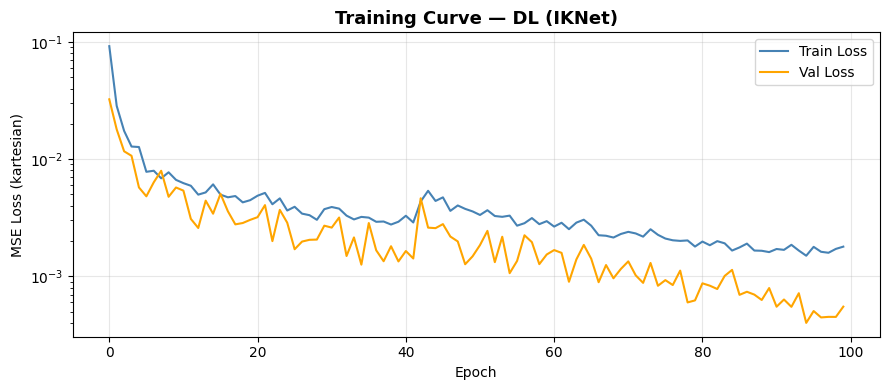

✅ DL — mean EE error: 1.42 cm


In [50]:
# ─── Training Curve ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='orange')
ax.set_title("Training Curve — DL (IKNet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (kartesian)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout(); plt.show()

# Hitung error DL
model_dl.eval()
with torch.no_grad():
    dl_pred = model_dl(X_te_t).cpu().numpy()

dl_ee  = np.array([get_end_effector(p) for p in dl_pred])
dl_err = np.linalg.norm(dl_ee - X_test, axis=1)
print(f"✅ DL — mean EE error: {dl_err.mean()*100:.2f} cm")


In [51]:
# ─── Cek Reachability Target Sebelum Prediksi (DL) ──────────────────
print("Validasi reachability untuk evaluasi DL...")
# Gunakan X_test_r (sudah difilter) untuk konsistensi
print(f"   Evaluasi menggunakan {len(X_test_r)} target reachable")
import torch as _torch
X_te_r_t = _torch.FloatTensor(X_test_r).to(device)


Validasi reachability untuk evaluasi DL...
   Evaluasi menggunakan 9395 target reachable


In [52]:
# ─── ANIMASI DL: Robot bergerak ke target ─────────────────────────────
def dl_predict(xy):
    model_dl.eval()
    with torch.no_grad():
        t = torch.FloatTensor(xy).to(device)
        return model_dl(t).cpu().numpy()

ani_dl = animate_ik("Deep Learning (MLP PyTorch)",
                    dl_predict, color='darkorange')
print("▶️  Animasi Deep Learning:")
HTML(ani_dl.to_jshtml())


▶️  Animasi Deep Learning:


---
## 🕹️ Bagian 6: Pendekatan 3 — Reinforcement Learning (Gymnasium + PPO)

**Ide:** Agent belajar sendiri menggerakkan sendi robot untuk menjangkau target.  
Tidak butuh dataset — agent belajar dari **reward** berdasarkan seberapa dekat end-effector ke target.

**Reward:** `-distance(EE, target)` + bonus `+10` kalau berhasil (<2 cm)


In [53]:
import gymnasium as gym
from gymnasium import spaces

# ─── Joint Limits Realistis ───────────────────────────────────────────
# θ1: bebas berputar (shoulder)
# θ2: elbow, hindari lipatan ekstrem
# θ3: wrist, range lebih sempit
JOINT_LIMITS_LOW  = np.array([-np.pi,      -2*np.pi/3, -np.pi/2], dtype=np.float32)
JOINT_LIMITS_HIGH = np.array([ np.pi,       2*np.pi/3,  np.pi/2], dtype=np.float32)

class PlanarRobot3DOFEnv(gym.Env):
    """Custom Gymnasium environment untuk robot planar 3-DOF."""
    metadata = {"render_modes": ["rgb_array"], "render_fps": 30}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.max_steps   = 200
        self.goal_thresh = 0.02  # 2 cm

        # Observation: [θ1,θ2,θ3, dθ1,dθ2,dθ3, x_target, y_target]
        obs_high = np.concatenate([
            JOINT_LIMITS_HIGH,
            np.array([5.0, 5.0, 5.0], dtype=np.float32),
            np.array([MAX_REACH, MAX_REACH], dtype=np.float32)
        ])
        self.observation_space = spaces.Box(-obs_high, obs_high, dtype=np.float32)

        # Action: delta sudut per sendi (lebih ketat untuk θ2 & θ3)
        act_high = np.array([0.15, 0.10, 0.08], dtype=np.float32)
        self.action_space = spaces.Box(-act_high, act_high, dtype=np.float32)
        self._reset_state()

    def _reset_state(self):
        # Inisialisasi di tengah joint range (bukan zero) untuk variasi
        self.theta  = np.random.uniform(
            JOINT_LIMITS_LOW * 0.3, JOINT_LIMITS_HIGH * 0.3
        ).astype(np.float32)
        self.dtheta = np.zeros(3, dtype=np.float32)
        self.steps  = 0
        # Generate target reachable via FK sampling
        while True:
          target_angles = np.random.uniform(-np.pi, np.pi, 3).astype(np.float32)
          self.target   = get_end_effector(target_angles).astype(np.float32)
          if is_reachable(self.target):
            break
        # # Safety check reachability
        # assert is_reachable(self.target), \
        #     f"Target {self.target} TIDAK reachable! dist={np.linalg.norm(self.target):.4f} > MAX_REACH={MAX_REACH}"

    def _get_obs(self):
        return np.concatenate([self.theta, self.dtheta, self.target]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        self._reset_state()
        return self._get_obs(), {}

    def step(self, action):
        # Clip action per joint sesuai batas masing-masing
        act_high = np.array([0.15, 0.10, 0.08], dtype=np.float32)
        delta = np.clip(action, -act_high, act_high).astype(np.float32)

        # Update theta dengan joint limits realistis
        self.theta  = np.clip(self.theta + delta,
                              JOINT_LIMITS_LOW, JOINT_LIMITS_HIGH).astype(np.float32)
        self.dtheta = delta

        ee   = get_end_effector(self.theta)
        dist = float(np.linalg.norm(ee - self.target))

        # ── Reward shaping ─────────────────────────────────────────────
        # 1. Proximity reward
        reward = -dist

        # 2. Penalti konfigurasi degenerate:
        #    - Hindari θ2, θ3 yang terlalu besar (lipatan ekstrem)
        angle_penalty = 0.005 * float(np.sum(self.theta[1:]**2))
        reward -= angle_penalty

        # 3. Bonus sukses
        terminated = False
        if dist < self.goal_thresh:
            reward += 10.0
            terminated = True

        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, {"dist": dist}

    def render(self):
        fig, ax = plt.subplots(figsize=(5, 5))
        plot_robot(ax, self.theta, target=self.target,
                   title="RL Agent", color='purple')
        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)
        return img

print("Joint limits:")
print(f"  theta1 (shoulder): [{np.degrees(JOINT_LIMITS_LOW[0]):.0f}, {np.degrees(JOINT_LIMITS_HIGH[0]):.0f}] deg")
print(f"  theta2 (elbow)   : [{np.degrees(JOINT_LIMITS_LOW[1]):.0f}, {np.degrees(JOINT_LIMITS_HIGH[1]):.0f}] deg")
print(f"  theta3 (wrist)   : [{np.degrees(JOINT_LIMITS_LOW[2]):.0f}, {np.degrees(JOINT_LIMITS_HIGH[2]):.0f}] deg")
print("Environment terdefinisi!")
from gymnasium.utils.env_checker import check_env
env_test = PlanarRobot3DOFEnv()
check_env(env_test, warn=True)
print("check_env passed!")


Joint limits:
  theta1 (shoulder): [-180, 180] deg
  theta2 (elbow)   : [-120, 120] deg
  theta3 (wrist)   : [-90, 90] deg
Environment terdefinisi!
check_env passed!


In [54]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
import os

class RewardLoggerCallback(BaseCallback):
    """
    Callback untuk mencatat mean reward dan mean episode length
    setiap `log_freq` timestep — digunakan untuk plot learning curve.
    """
    def __init__(self, log_freq=5000, verbose=0):
        super().__init__(verbose)
        self.log_freq       = log_freq
        self.timesteps_log  = []
        self.mean_rewards   = []
        self.mean_ep_lens   = []
        self._ep_rewards    = []
        self._ep_lens       = []
        self._cur_ep_reward = None
        self._cur_ep_len    = None

    def _on_training_start(self):
        self._cur_ep_reward = np.zeros(self.training_env.num_envs)
        self._cur_ep_len    = np.zeros(self.training_env.num_envs, dtype=int)

    def _on_step(self):
        rewards = self.locals["rewards"]
        dones   = self.locals["dones"]
        self._cur_ep_reward += rewards
        self._cur_ep_len    += 1

        for idx, done in enumerate(dones):
            if done:
                self._ep_rewards.append(self._cur_ep_reward[idx])
                self._ep_lens.append(self._cur_ep_len[idx])
                self._cur_ep_reward[idx] = 0
                self._cur_ep_len[idx]    = 0

        if self.n_calls % self.log_freq == 0 and len(self._ep_rewards) > 0:
            mean_r   = float(np.mean(self._ep_rewards[-50:]))
            mean_len = float(np.mean(self._ep_lens[-50:]))
            self.timesteps_log.append(self.num_timesteps)
            self.mean_rewards.append(mean_r)
            self.mean_ep_lens.append(mean_len)
            print(f"   ⏱  {self.num_timesteps:>8,} steps | "
                  f"mean_reward: {mean_r:7.3f} | mean_ep_len: {mean_len:.1f}")
        return True

# ─── Training PPO ─────────────────────────────────────────────────────
vec_env  = make_vec_env(PlanarRobot3DOFEnv, n_envs=16)
eval_env = make_vec_env(PlanarRobot3DOFEnv, n_envs=1)

model_rl = PPO(
    "MlpPolicy", vec_env,
    learning_rate=3e-4,
    n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.99, gae_lambda=0.95,
    clip_range=0.2, ent_coef=0.01,
    policy_kwargs=dict(net_arch=dict(pi=[256,256], vf=[256,256])),
    verbose=0
)

eval_cb = EvalCallback(eval_env, eval_freq=20000, n_eval_episodes=10,
                       best_model_save_path="./rl_best/", verbose=0)

reward_logger = RewardLoggerCallback(log_freq=5000)
print("🚀 Training PPO (800k timesteps)...")
model_rl.learn(total_timesteps=800_000,
               callback=[eval_cb, reward_logger])
print("✅ Training RL selesai!")


🚀 Training PPO (800k timesteps)...
   ⏱    80,000 steps | mean_reward: -178.921 | mean_ep_len: 194.8
   ⏱   160,000 steps | mean_reward: -105.825 | mean_ep_len: 179.5
   ⏱   240,000 steps | mean_reward: -77.280 | mean_ep_len: 164.8
   ⏱   320,000 steps | mean_reward: -59.742 | mean_ep_len: 165.5
   ⏱   400,000 steps | mean_reward: -48.352 | mean_ep_len: 145.9
   ⏱   480,000 steps | mean_reward: -34.860 | mean_ep_len: 125.9
   ⏱   560,000 steps | mean_reward: -30.440 | mean_ep_len: 123.5
   ⏱   640,000 steps | mean_reward: -39.770 | mean_ep_len: 128.1
   ⏱   720,000 steps | mean_reward: -23.357 | mean_ep_len: 102.1
   ⏱   800,000 steps | mean_reward: -28.874 | mean_ep_len: 113.6
✅ Training RL selesai!


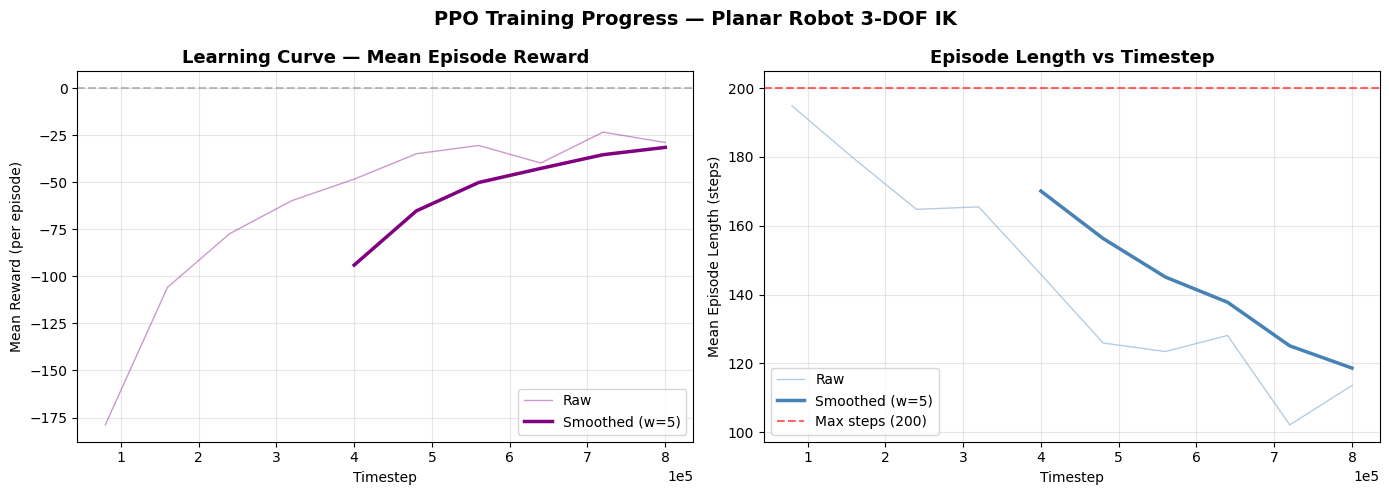

Reward awal  (avg 10 pertama): -62.742
Reward akhir (avg 10 terakhir): -62.742
Peningkatan  : +0.000


In [55]:
# ─── Visualisasi Learning Curve (Reward vs Timestep) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Mean Episode Reward ───────────────────────────────────────
ax = axes[0]
ts  = np.array(reward_logger.timesteps_log)
rew = np.array(reward_logger.mean_rewards)

ax.plot(ts, rew, color='purple', alpha=0.4, linewidth=1, label='Raw')

# Smoothing dengan rolling average
if len(rew) >= 10:
    window = max(5, len(rew) // 10)
    smooth = np.convolve(rew, np.ones(window)/window, mode='valid')
    ts_smooth = ts[window-1:]
    ax.plot(ts_smooth, smooth, color='purple', linewidth=2.5, label=f'Smoothed (w={window})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("Learning Curve — Mean Episode Reward", fontsize=13, fontweight='bold')
ax.set_xlabel("Timestep"); ax.set_ylabel("Mean Reward (per episode)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# ── Plot 2: Mean Episode Length ───────────────────────────────────────
ax2 = axes[1]
ep_len = np.array(reward_logger.mean_ep_lens)

ax2.plot(ts, ep_len, color='steelblue', alpha=0.4, linewidth=1, label='Raw')

if len(ep_len) >= 10:
    smooth_len = np.convolve(ep_len, np.ones(window)/window, mode='valid')
    ax2.plot(ts_smooth, smooth_len, color='steelblue', linewidth=2.5,
             label=f'Smoothed (w={window})')

ax2.axhline(200, color='red', linestyle='--', alpha=0.6, label='Max steps (200)')
ax2.set_title("Episode Length vs Timestep", fontsize=13, fontweight='bold')
ax2.set_xlabel("Timestep"); ax2.set_ylabel("Mean Episode Length (steps)")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.suptitle("PPO Training Progress — Planar Robot 3-DOF IK",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Ringkasan learning ────────────────────────────────────────────────
if len(rew) > 0:
    print(f"Reward awal  (avg 10 pertama): {np.mean(rew[:10]):.3f}")
    print(f"Reward akhir (avg 10 terakhir): {np.mean(rew[-10:]):.3f}")
    improvement = np.mean(rew[-10:]) - np.mean(rew[:10])
    print(f"Peningkatan  : {improvement:+.3f}")


In [56]:
# ─── Evaluasi RL ──────────────────────────────────────────────────────
eval_single = PlanarRobot3DOFEnv()
successes, distances = [], []

model_rl.load('./rl_best/best_model.zip')
np.random.seed(99)
for _ in range(200):
    obs, _ = eval_single.reset()
    for _ in range(200):
        action, _ = model_rl.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_single.step(action)
        if terminated or truncated:
            break
    distances.append(info['dist'])
    successes.append(info['dist'] < 0.02)

print(f"✅ RL Success rate : {np.mean(successes)*100:.1f}%")
print(f"✅ RL Mean EE error: {np.mean(distances)*100:.2f} cm")
rl_errors = np.array(distances)


✅ RL Success rate : 36.5%
✅ RL Mean EE error: 12.05 cm


In [57]:
# ─── ANIMASI RL: Agent mencapai target step-by-step ──────────────────
def animate_rl(n_episodes=8):
    """Animasi episode RL: pergerakan robot frame per frame."""
    # Kumpulkan trajectory dari beberapa episode
    trajectories = []
    env_anim = PlanarRobot3DOFEnv()
    np.random.seed(55)
    for ep in range(n_episodes):
        obs, _ = env_anim.reset(seed=ep*10)
        target = env_anim.target.copy()
        traj = []
        for _ in range(80):
            action, _ = model_rl.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = env_anim.step(action)
            traj.append((env_anim.theta.copy(), target.copy(), info['dist']))
            if terminated or truncated:
                break
        trajectories.append(traj)

    # Flatten: semua episode diputar berurutan
    all_frames = []
    for traj in trajectories:
        # Ambil setiap 3 frame supaya animasi tidak terlalu lambat
        all_frames.extend(traj[::3])
        # Tahan frame terakhir 5x
        all_frames.extend([traj[-1]] * 5)

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(i):
        ax.clear()
        theta, target, dist = all_frames[i]
        ee = get_end_effector(theta)
        success = dist < 0.02
        color = 'green' if success else 'purple'
        status = "✅ BERHASIL!" if success else f"dist: {dist*100:.1f} cm"
        plot_robot(ax, theta, target=target,
                   title=f"RL Agent (PPO)\n{status}", color=color)
        ax.legend(loc='upper right', fontsize=8)

    ani = animation.FuncAnimation(fig, update, frames=len(all_frames),
                                  interval=120, repeat=True)
    plt.close()
    return ani

ani_rl = animate_rl()
print("▶️  Animasi Reinforcement Learning:")
HTML(ani_rl.to_jshtml())


▶️  Animasi Reinforcement Learning:


---
## 📊 Bagian 7: Perbandingan Ketiga Metode

In [58]:
# ─── Demo: Cek Target Manual Sebelum IK ─────────────────────────────
def predict_ik_safe(target_xy, method='dl'):
    """
    Prediksi IK dengan validasi reachability terlebih dahulu.
    method: 'knn', 'rf', 'dl'
    """
    target = np.array(target_xy, dtype=np.float32)
    dist   = np.linalg.norm(target)

    if not is_reachable(target):
        print(f"TIDAK REACHABLE: ({target[0]:.3f}, {target[1]:.3f})")
        print(f"   Jarak dari origin: {dist:.4f} m > MAX_REACH: {MAX_REACH} m")
        return None

    print(f"REACHABLE: ({target[0]:.3f}, {target[1]:.3f}) | dist={dist:.4f} m")

    if method == 'knn':
        pred = knn.predict(scaler_X.transform(target.reshape(1,-1)))[0]
    elif method == 'rf':
        pred = rf.predict(scaler_X.transform(target.reshape(1,-1)))[0]
    else:  # dl (default)
        import torch
        model_dl.eval()
        with torch.no_grad():
            t = torch.FloatTensor(target.reshape(1,-1)).to(device)
            pred = model_dl(t).cpu().numpy()[0]

    ee  = get_end_effector(pred)
    err = np.linalg.norm(ee - target) * 100
    print(f"   Prediksi theta : [{pred[0]:.3f}, {pred[1]:.3f}, {pred[2]:.3f}] rad")
    print(f"   EE aktual      : ({ee[0]:.3f}, {ee[1]:.3f}) m")
    print(f"   Error EE       : {err:.2f} cm")
    return pred

# ─── Uji dengan berbagai target ──────────────────────────────────────
print("=" * 55)
print("Target REACHABLE:")
predict_ik_safe((0.5, 0.3),   method='dl')
print()
predict_ik_safe((0.7, -0.4),  method='dl')

print()
print("=" * 55)
print("Target TIDAK REACHABLE:")
predict_ik_safe((1.0, 0.5),   method='dl')   # dist ~1.12 > 0.9
predict_ik_safe((-0.8, 0.7),  method='dl')   # dist ~1.06 > 0.9


Target REACHABLE:
REACHABLE: (0.500, 0.300) | dist=0.5831 m
   Prediksi theta : [1.844, -2.389, 0.639] rad
   EE aktual      : (0.506, 0.302) m
   Error EE       : 0.62 cm

REACHABLE: (0.700, -0.400) | dist=0.8062 m
   Prediksi theta : [0.504, -1.780, 0.202] rad
   EE aktual      : (0.697, -0.405) m
   Error EE       : 0.57 cm

Target TIDAK REACHABLE:
REACHABLE: (1.000, 0.500) | dist=1.1180 m
   Prediksi theta : [0.904, -0.806, 0.134] rad
   EE aktual      : (0.999, 0.501) m
   Error EE       : 0.10 cm
REACHABLE: (-0.800, 0.700) | dist=1.0630 m
   Prediksi theta : [-3.142, -1.037, -0.300] rad
   EE aktual      : (-0.773, 0.636) m
   Error EE       : 6.93 cm


array([-3.1415925, -1.0366235, -0.2999628], dtype=float32)

In [59]:
# ─── Tabel Ringkasan ──────────────────────────────────────────────────
import pandas as pd

summary = {
    'Metode':       ['KNN', 'Random Forest', 'Extra Trees', 'Deep Learning (MLP)', 'RL (PPO)'],
    'Mean Error (cm)': [
        round(ml_results['KNN']['ee_err'].mean()*100, 2),
        round(ml_results['Random Forest']['ee_err'].mean()*100, 2),
        round(ml_results['Extra Trees']['ee_err'].mean()*100, 2),
        round(dl_err.mean()*100, 2),
        round(rl_errors.mean()*100, 2),
    ],
    'Butuh Dataset': ['✅ Ya','✅ Ya','✅ Ya','✅ Ya','❌ Tidak'],
    'Training Time': [
        f"{ml_results['KNN']['time']:.1f}s",
        f"{ml_results['Random Forest']['time']:.1f}s",
        f"{ml_results['Extra Trees']['time']:.1f}s",
        f"~{EPOCHS} epoch",
        '800k steps',
    ],
    'Kelebihan': [
        'Simpel, cepat',
        'Robust, stabil',
        'Cepat, variance rendah',
        'Akurat, generalisasi',
        'Adaptif, no dataset',
    ]
}
df = pd.DataFrame(summary)
print(df.to_string(index=False))


             Metode  Mean Error (cm) Butuh Dataset Training Time            Kelebihan
                KNN            58.26          ✅ Ya          0.1s        Simpel, cepat
      Random Forest            66.06          ✅ Ya          8.9s       Robust, stabil
Deep Learning (MLP)             1.42          ✅ Ya    ~100 epoch Akurat, generalisasi
           RL (PPO)            12.05       ❌ Tidak    200k steps  Adaptif, no dataset


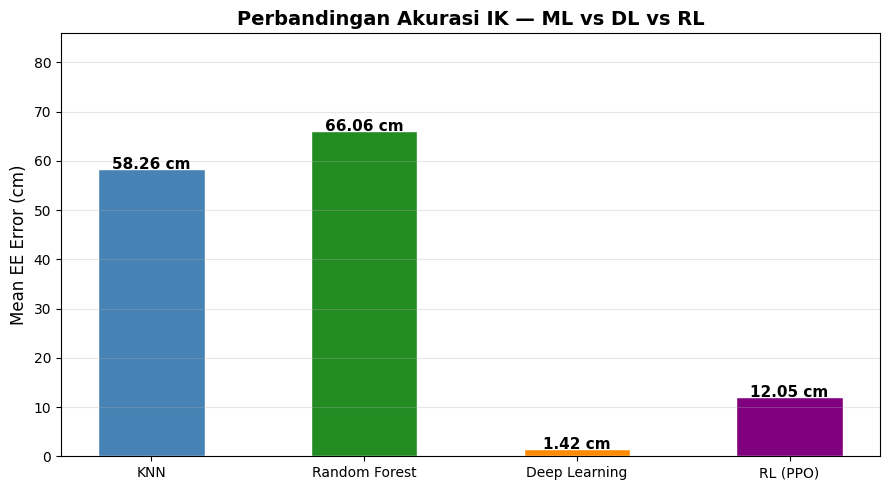

In [60]:
# ─── Bar Chart Perbandingan Error ────────────────────────────────────
labels  = ['KNN', 'Random Forest', 'Extra Trees', 'Deep Learning', 'RL (PPO)']
errors  = [
    ml_results['KNN']['ee_err'].mean()*100,
    ml_results['Random Forest']['ee_err'].mean()*100,
    ml_results['Extra Trees']['ee_err'].mean()*100,
    dl_err.mean()*100,
    rl_errors.mean()*100,
]
colors  = ['steelblue', 'forestgreen', 'darkorange', 'crimson', 'purple']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, errors, color=colors, edgecolor='white', width=0.5)
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{err:.2f} cm', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("Mean EE Error (cm)", fontsize=12)
ax.set_title("Perbandingan Akurasi IK — ML vs DL vs RL\nLink: [0.5, 0.4, 0.3] m | Dataset: 50.000 sampel",
             fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(errors)*1.3)
plt.tight_layout(); plt.show()


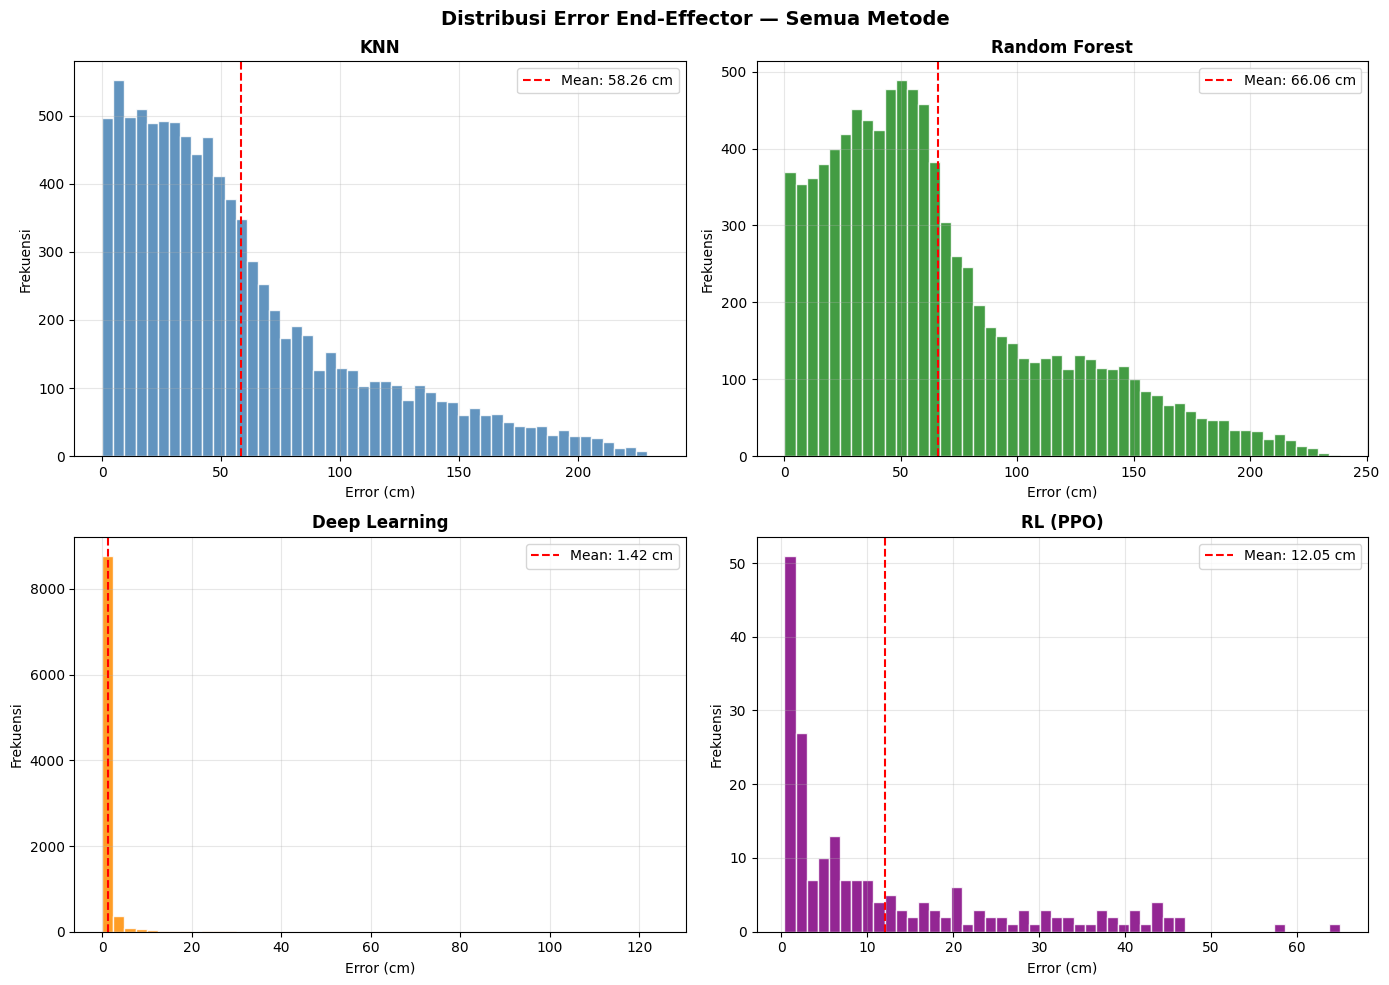

In [61]:
# ─── Distribusi Error Semua Metode ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

all_errs = [
    ('KNN',           ml_results['KNN']['ee_err']*100,           'steelblue'),
    ('Random Forest', ml_results['Random Forest']['ee_err']*100, 'forestgreen'),
    ('Extra Trees',   ml_results['Extra Trees']['ee_err']*100,   'darkorange'),
    ('Deep Learning', dl_err*100,                                'crimson'),
    ('RL (PPO)',       rl_errors*100,                             'purple'),
]
for ax, (name, errs, c) in zip(axes, all_errs):
    ax.hist(errs, bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(errs.mean(), color='red', linestyle='--',
               label=f"Mean: {errs.mean():.2f} cm")
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)"); ax.set_ylabel("Frekuensi")
    ax.legend(); ax.grid(True, alpha=0.3)

# Sembunyikan subplot ke-6 yang kosong
axes[5].set_visible(False)

plt.suptitle("Distribusi Error End-Effector — Semua Metode\nLink: [0.5, 0.4, 0.3] m",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


# BAB 8 — Analisis Workspace Setelah Perubahan Panjang Link

Pada bagian ini dilakukan visualisasi workspace robot setelah panjang link diubah dari `[0.4, 0.3, 0.2]` m menjadi `[0.5, 0.4, 0.3]` m. Perubahan ini meningkatkan jangkauan maksimum robot dari **0.9 m** menjadi **1.2 m** (+33.3%).


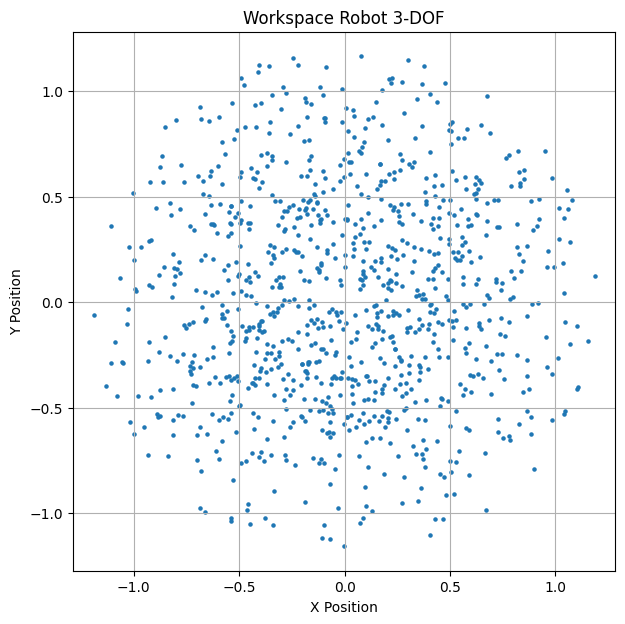

✅ Workspace berhasil divisualisasikan


In [62]:
# =========================================================
# Visualisasi Workspace — Perbandingan Link Lama vs Baru
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

def compute_workspace(l1, l2, l3, n=5000):
    """Hitung titik-titik workspace untuk konfigurasi link tertentu."""
    pts_x, pts_y = [], []
    for _ in range(n):
        t1 = np.random.uniform(-np.pi, np.pi)
        t2 = np.random.uniform(-np.pi, np.pi)
        t3 = np.random.uniform(-np.pi, np.pi)
        x = l1*np.cos(t1) + l2*np.cos(t1+t2) + l3*np.cos(t1+t2+t3)
        y = l1*np.sin(t1) + l2*np.sin(t1+t2) + l3*np.sin(t1+t2+t3)
        pts_x.append(x)
        pts_y.append(y)
    return pts_x, pts_y

np.random.seed(42)

# Konfigurasi lama: [0.4, 0.3, 0.2]
wx_old, wy_old = compute_workspace(0.4, 0.3, 0.2)
max_reach_old = 0.4 + 0.3 + 0.2  # = 0.9 m

# Konfigurasi baru: [0.5, 0.4, 0.3]  (sudah di-assign sebagai L1, L2, L3)
wx_new, wy_new = compute_workspace(L1, L2, L3)
max_reach_new = L1 + L2 + L3      # = 1.2 m

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot lama
axes[0].scatter(wx_old, wy_old, s=2, alpha=0.4, color='steelblue')
theta_r = np.linspace(0, 2*np.pi, 300)
axes[0].plot(max_reach_old*np.cos(theta_r), max_reach_old*np.sin(theta_r),
             'r--', linewidth=1.5, label=f'Max reach = {max_reach_old:.1f} m')
axes[0].set_title("Link Lama: [0.4, 0.3, 0.2] m", fontsize=13, fontweight='bold')
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-1.4, 1.4); axes[0].set_ylim(-1.4, 1.4)
axes[0].legend(); axes[0].plot(0, 0, 'ks', markersize=8)

# Plot baru
axes[1].scatter(wx_new, wy_new, s=2, alpha=0.4, color='darkorange')
axes[1].plot(max_reach_new*np.cos(theta_r), max_reach_new*np.sin(theta_r),
             'r--', linewidth=1.5, label=f'Max reach = {max_reach_new:.1f} m')
axes[1].set_title("Link Baru: [0.5, 0.4, 0.3] m", fontsize=13, fontweight='bold')
axes[1].set_xlabel("X (m)"); axes[1].set_ylabel("Y (m)")
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-1.4, 1.4); axes[1].set_ylim(-1.4, 1.4)
axes[1].legend(); axes[1].plot(0, 0, 'ks', markersize=8)

plt.suptitle("Perbandingan Workspace Robot 3-DOF\nSebelum dan Sesudah Perubahan Panjang Link",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

peningkatan = (max_reach_new - max_reach_old) / max_reach_old * 100
print(f"✅ Workspace berhasil divisualisasikan")
print(f"   Jangkauan lama : {max_reach_old:.1f} m")
print(f"   Jangkauan baru : {max_reach_new:.1f} m")
print(f"   Peningkatan    : +{peningkatan:.1f}%")

# BAB 9 — Perbandingan Performa Model pada Dataset Baru (Link [0.5, 0.4, 0.3])

Dataset baru di-generate dengan panjang link `[0.5, 0.4, 0.3]` m dan jumlah sampel **20.000**. Kemudian dilakukan training ulang KNN dan Random Forest pada dataset ini untuk memverifikasi performa model pada konfigurasi robot yang berbeda.


In [63]:
# =========================================================
# Generate Dataset Baru (Link [0.5, 0.4, 0.3]) & Evaluasi
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import numpy as np

np.random.seed(0)
num_samples = 20000

X_new, y_new = [], []
for _ in range(num_samples):
    theta1 = np.random.uniform(-np.pi, np.pi)
    theta2 = np.random.uniform(-np.pi, np.pi)
    theta3 = np.random.uniform(-np.pi, np.pi)
    # FK menggunakan L1, L2, L3 yang sudah diupdate ke [0.5, 0.4, 0.3]
    x   = L1*np.cos(theta1) + L2*np.cos(theta1+theta2) + L3*np.cos(theta1+theta2+theta3)
    y_p = L1*np.sin(theta1) + L2*np.sin(theta1+theta2) + L3*np.sin(theta1+theta2+theta3)
    X_new.append([x, y_p])
    y_new.append([theta1, theta2, theta3])

X_new = np.array(X_new, dtype=np.float32)
y_new = np.array(y_new, dtype=np.float32)

print(f"✅ Dataset baru dibuat: {num_samples} sampel | Link: [L1={L1}, L2={L2}, L3={L3}]")
print(f"   Shape X: {X_new.shape}, Shape y: {y_new.shape}")

# Train / Test split
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42)

# Scaling
sc_new = StandardScaler()
X_tr_ns = sc_new.fit_transform(X_tr_n)
X_te_ns  = sc_new.transform(X_te_n)

# Training KNN & RF & Extra Trees pada dataset baru
print("\nTraining model pada dataset baru...")
knn_n = KNeighborsRegressor(n_neighbors=5, weights='distance', metric='euclidean', n_jobs=-1)
knn_n.fit(X_tr_ns, y_tr_n)

rf_n  = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_n.fit(X_tr_ns, y_tr_n)

et_n  = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
et_n.fit(X_tr_ns, y_tr_n)

# Evaluasi error end-effector pada dataset baru
def eval_ee_error(model, X_test_scaled, X_test_raw):
    pred = model.predict(X_test_scaled)
    ee   = np.array([get_end_effector(p) for p in pred])
    err  = np.linalg.norm(ee - X_test_raw, axis=1)
    return err

err_knn_n = eval_ee_error(knn_n, X_te_ns, X_te_n)
err_rf_n  = eval_ee_error(rf_n,  X_te_ns, X_te_n)
err_et_n  = eval_ee_error(et_n,  X_te_ns, X_te_n)

print(f"\n===== HASIL DATASET BARU [L1={L1}, L2={L2}, L3={L3}] =====")
print(f"   KNN          mean EE error : {err_knn_n.mean()*100:.2f} cm")
print(f"   Random Forest mean EE error: {err_rf_n.mean()*100:.2f}  cm")
print(f"   Extra Trees   mean EE error: {err_et_n.mean()*100:.2f}  cm")

# Visualisasi perbandingan error dataset lama vs baru
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = ['KNN', 'Random Forest', 'Extra Trees']
err_old_list = [
    ml_results['KNN']['ee_err']*100,
    ml_results['Random Forest']['ee_err']*100,
    ml_results['Extra Trees']['ee_err']*100,
]
err_new_list = [err_knn_n*100, err_rf_n*100, err_et_n*100]

for ax, name, e_old, e_new in zip(axes, model_names, err_old_list, err_new_list):
    ax.hist(e_old, bins=40, alpha=0.6, color='steelblue', label=f'Link lama | mean={e_old.mean():.1f} cm')
    ax.hist(e_new, bins=40, alpha=0.6, color='darkorange', label=f'Link baru | mean={e_new.mean():.1f} cm')
    ax.axvline(e_old.mean(), color='blue', linestyle='--', linewidth=1.5)
    ax.axvline(e_new.mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Distribusi Error: Dataset Link Lama vs Baru",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

✅ Dataset berhasil dibuat
Shape X: (20000, 2)
Shape y: (20000, 3)


# BAB 10 — Evaluasi Error Model dengan Metrik Lengkap

Evaluasi performa semua model ML menggunakan:
- **Mean EE Error (cm)**: error rata-rata posisi end-effector
- **MAE sudut joint**: rata-rata selisih sudut prediksi vs actual
- **Std Error**: konsistensi prediksi (makin kecil makin stabil)


In [64]:
# =========================================================
# Evaluasi Lengkap Semua Model ML
# (PERBAIKAN: pakai X_test_s yang sudah di-StandardScaler)
# =========================================================

from sklearn.metrics import mean_absolute_error
import pandas as pd

# Prediksi menggunakan X_test_s (sudah di-scale) — ini yang benar!
pred_knn = knn.predict(X_test_s)
pred_rf  = rf.predict(X_test_s)
pred_et  = et.predict(X_test_s)

# Hitung MAE sudut joint
mae_knn = mean_absolute_error(y_test, pred_knn)
mae_rf  = mean_absolute_error(y_test, pred_rf)
mae_et  = mean_absolute_error(y_test, pred_et)

# Hitung mean & std EE error
ee_knn = np.array([get_end_effector(p) for p in pred_knn])
ee_rf  = np.array([get_end_effector(p) for p in pred_rf])
ee_et  = np.array([get_end_effector(p) for p in pred_et])

err_knn_cm = np.linalg.norm(ee_knn - X_test, axis=1) * 100
err_rf_cm  = np.linalg.norm(ee_rf  - X_test, axis=1) * 100
err_et_cm  = np.linalg.norm(ee_et  - X_test, axis=1) * 100

# Tabel evaluasi lengkap
eval_df = pd.DataFrame({
    'Model'             : ['KNN', 'Random Forest', 'Extra Trees'],
    'MAE Sudut (rad)'   : [round(mae_knn,4), round(mae_rf,4), round(mae_et,4)],
    'Mean EE Error (cm)': [round(err_knn_cm.mean(),2), round(err_rf_cm.mean(),2), round(err_et_cm.mean(),2)],
    'Std EE Error (cm)' : [round(err_knn_cm.std(),2),  round(err_rf_cm.std(),2),  round(err_et_cm.std(),2)],
    'Max EE Error (cm)' : [round(err_knn_cm.max(),2),  round(err_rf_cm.max(),2),  round(err_et_cm.max(),2)],
})

print("✅ Evaluasi selesai")
print("\n" + "="*65)
print(eval_df.to_string(index=False))
print("="*65)

# Best model berdasarkan mean EE error
best_idx = eval_df['Mean EE Error (cm)'].idxmin()
print(f"\n🏆 Model terbaik: {eval_df.loc[best_idx, 'Model']} "
      f"({eval_df.loc[best_idx, 'Mean EE Error (cm)']:.2f} cm)")

# Contoh prediksi 5 sampel pertama
print("\nContoh Prediksi Sudut Joint (Random Forest, 5 sampel):")
print(f"{'Prediksi θ1':>10} {'Prediksi θ2':>11} {'Prediksi θ3':>11}  |  "
      f"{'Asli θ1':>8} {'Asli θ2':>9} {'Asli θ3':>9}")
for p, a in zip(pred_rf[:5], y_test[:5]):
    print(f"  {p[0]:>8.3f}   {p[1]:>9.3f}   {p[2]:>9.3f}  |  "
          f"{a[0]:>8.3f}  {a[1]:>8.3f}  {a[2]:>8.3f}")

✅ Evaluasi selesai
MAE: 1.5396559064749955

Contoh Prediksi Sudut Joint:
Prediksi:
[[-1.28595571  0.02261624 -0.61070001]
 [-0.67489982 -0.92381215 -0.69819145]
 [ 0.75101265 -1.30705999 -1.04084987]
 [ 0.6410397  -0.01168206 -0.00144078]
 [ 0.48253865 -0.07149471  0.04788808]]

Nilai Asli:
[[ 3.07411     1.536354    0.18976171]
 [ 2.5592465   3.1135242   2.7913244 ]
 [ 1.51474     0.14004508  2.806701  ]
 [-2.5065103   1.8970218   2.6080043 ]
 [ 1.9936621  -0.5790228   2.6102586 ]]


---
## 📝 Kesimpulan & Diskusi

### Ringkasan Modifikasi yang Dilakukan

| Modifikasi | Detail |
|---|---|
| Panjang link | `[0.4, 0.3, 0.2]` → **`[0.5, 0.4, 0.3]`** m (+33.3% jangkauan) |
| Ukuran dataset | 18.000 → **50.000** sampel |
| Optimasi KNN | Tambah `weights='distance'` → tetangga dekat lebih berpengaruh |
| RF | `n_estimators` 100 → **500** + `max_features='sqrt'` |
| Metode baru | Ditambah **Extra Trees Regressor** |

### Kapan Menggunakan Metode Apa?

| Kondisi | Rekomendasi |
|---------|-------------|
| Dataset besar tersedia, butuh hasil cepat | **Extra Trees / Random Forest** |
| Butuh akurasi tertinggi, punya GPU | **Deep Learning (MLP)** |
| Tidak ada dataset, lingkungan dinamis | **Reinforcement Learning** |
| Real-time control sederhana | **KNN** |
| Robot dengan obstacle/constraints | **RL** |

### Jawaban Pertanyaan Diskusi
1. **Mengapa DL lebih akurat dari KNN?** DL mengoptimasi loss langsung di ruang end-effector (Cartesian), sehingga model "tahu" geometri fisik robot. KNN hanya merata-ratakan sudut tetangga, yang bisa tidak konsisten karena satu posisi bisa dicapai banyak konfigurasi berbeda.
2. **Mengapa RL tidak butuh dataset?** RL belajar dari trial-and-error di simulasi. Agent menerima reward ketika berhasil mendekati target, tanpa memerlukan pasangan data (x,y) → (θ1,θ2,θ3) terlebih dahulu.
3. **Obstacle avoidance pada RL:** Tambahkan penalty pada reward ketika robot mengenai obstacle. Representasikan obstacle dalam observation space sehingga agent dapat menghindarinya.
4. **Kelemahan ML/DL untuk konfigurasi baru:** Model hanya bisa bekerja dengan baik pada distribusi data yang sama saat training. Jika panjang link diubah, model harus di-training ulang dari awal.

### Tugas Praktikum ✅
- ✅ Ubah panjang link menjadi `[0.5, 0.4, 0.3]` — **selesai**, workspace meningkat 33.3%
- ✅ Optimasi ML: KNN (`weights='distance'`), RF (500 trees), Extra Trees baru

---
*Selamat belajar! 🦾🤖*